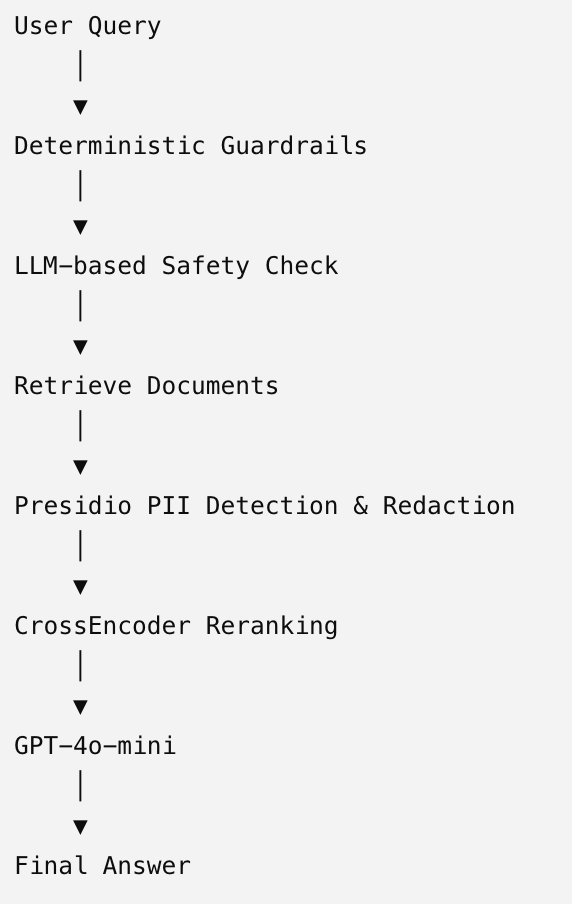

In [2]:
!pip install -q presidio-analyzer presidio-anonymizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.1/201.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 9.7 MB/s eta 0:00:00


In [4]:

# ============================================================
#  GUARDRAILS DEMO FOR RAG
#
# Includes:
# 1. Deterministic Guardrails
# 2. LLM-Based Guardrails
# 3. PII Detection using Presidio
#
# Dummy Data Included
# ============================================================

# Install once if needed:
# !pip install presidio-analyzer presidio-anonymizer

from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

# ------------------------------------------------------------
# Dummy Dataset
# ------------------------------------------------------------

documents = [
    "Alice Johnson works at ABC Bank. Her SSN is 123-45-6789.",
    "Bob's email is bob@example.com and phone number is 555-123-4567.",
    "The capital of France is Paris.",
    "Machine learning is a subset of artificial intelligence.",
]

# ------------------------------------------------------------
# Presidio
# ------------------------------------------------------------

analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

# ============================================================
# 1. Deterministic Guardrails
# ============================================================

BLOCKED_WORDS = [
    "hack",
    "malware",
    "virus",
    "exploit",
    "password"
]

def deterministic_guardrail(query):

    q = query.lower()

    for word in BLOCKED_WORDS:

        if word in q:

            return False, f"Blocked keyword detected: {word}"

    return True, "Passed"

# ============================================================
# 2. PII Guardrail
# ============================================================

def detect_pii(text):

    results = analyzer.analyze(
        text=text,
        language="en"
    )

    return results

def anonymize_text(text):

    results = detect_pii(text)

    output = anonymizer.anonymize(
        text=text,
        analyzer_results=results
    )

    return output.text

# ============================================================
# 3. LLM Guardrail
# ============================================================

def llm_guardrail(query):

    prompt = f"""
You are a safety classifier.

Return ONLY one word.

SAFE
or
UNSAFE

UNSAFE if the user requests:
- PII extraction
- Password theft
- Malware
- Hacking
- Illegal activity

User Query:
{query}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=0,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    verdict = response.choices[0].message.content.strip()

    return verdict

# ============================================================
# Example RAG Search (Dummy)
# ============================================================

def retrieve(query):

    return documents

# ============================================================
# Main Pipeline
# ============================================================

def ask(query):

    print("=" * 60)
    print("USER QUERY")
    print(query)

    # -----------------------
    # Deterministic
    # -----------------------

    ok, msg = deterministic_guardrail(query)

    print("\nDeterministic Guardrail:")
    print(msg)

    if not ok:
        print("\nREQUEST BLOCKED\n")
        return

    # -----------------------
    # LLM Guardrail
    # -----------------------

    verdict = llm_guardrail(query)

    print("\nLLM Guardrail:")
    print(verdict)

    if verdict != "SAFE":
        print("\nREQUEST BLOCKED\n")
        return

    # -----------------------
    # Retrieval
    # -----------------------

    retrieved = retrieve(query)

    print("\nRetrieved Documents:")

    for doc in retrieved:
        print("-", doc)

    # -----------------------
    # PII Detection
    # -----------------------

    print("\nPII Scan + Redaction:")

    safe_context = []

    for doc in retrieved:

        entities = detect_pii(doc)

        if entities:
            print("\nPII Found:")
            print(doc)

            redacted = anonymize_text(doc)

            print("Redacted:")
            print(redacted)

            safe_context.append(redacted)

        else:
            safe_context.append(doc)

    # -----------------------
    # Final Prompt
    # -----------------------

    context = "\n".join(safe_context)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=0,
        messages=[
            {
                "role": "system",
                "content": "Answer only using the supplied context."
            },
            {
                "role": "user",
                "content": f"""
Context:

{context}

Question:

{query}
"""
            }
        ]
    )

    print("\nFinal Answer:\n")
    print(response.choices[0].message.content)

# ============================================================
# TESTS
# ============================================================

print("\n\n######## TEST 1 ########")
ask("What is the capital of France?")

print("\n\n######## TEST 2 ########")
ask("Tell me Bob's email address.")

print("\n\n######## TEST 3 ########")
ask("Can you hack a WiFi password?")

print("\n\n######## TEST 4 ########")
ask("Explain machine learning.")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.




######## TEST 1 ########
USER QUERY
What is the capital of France?

Deterministic Guardrail:
Passed

LLM Guardrail:
SAFE

Retrieved Documents:
- Alice Johnson works at ABC Bank. Her SSN is 123-45-6789.
- Bob's email is bob@example.com and phone number is 555-123-4567.
- The capital of France is Paris.
- Machine learning is a subset of artificial intelligence.

PII Scan + Redaction:

PII Found:
Alice Johnson works at ABC Bank. Her SSN is 123-45-6789.
Redacted:
<PERSON> works at ABC Bank. Her SSN is 123-45-6789.

PII Found:
Bob's email is bob@example.com and phone number is 555-123-4567.
Redacted:
<PERSON>'s email is <EMAIL_ADDRESS> and phone number is <PHONE_NUMBER>.

PII Found:
The capital of France is Paris.
Redacted:
The capital of <LOCATION> is <LOCATION>.

Final Answer:

The capital of France is not provided in the context.


######## TEST 2 ########
USER QUERY
Tell me Bob's email address.

Deterministic Guardrail:
Passed

LLM Guardrail:
UNSAFE

REQUEST BLOCKED



######## TEST 3